# Lesson 2.5 — SIMPLE Algorithm

## The Predictor-Corrector Idea

SIMPLE (Semi-Implicit Method for Pressure-Linked Equations, Patankar & Spalding, 1972) is
a **predictor-corrector** approach:

1. **Predict** a velocity field from momentum, using a *guessed* pressure $p^*$.
2. **Correct** the velocity and pressure so that continuity is satisfied.

The correction is derived by requiring $\nabla\cdot\mathbf{u}^{n+1} = 0$. This leads to a
Poisson equation for the **pressure correction** $p'$.

---

## The SIMPLE Steps

Given $(\mathbf{u}^n, p^n)$:

**Step 1 — Momentum predictor**: solve momentum with $p = p^*$ (= $p^n$ on first iteration):

$$\frac{\mathbf{u}^* - \mathbf{u}^n}{\Delta t} = -\frac{1}{\rho}\nabla p^* - (\mathbf{u}^n\cdot\nabla)\mathbf{u}^n + \nu\nabla^2\mathbf{u}^n$$

$\mathbf{u}^*$ generally does not satisfy $\nabla\cdot\mathbf{u}^* = 0$.

**Step 2 — Pressure Poisson equation**: write $\mathbf{u} = \mathbf{u}^* - \frac{\Delta t}{\rho}\nabla p'$.
Apply continuity:

$$\nabla^2 p' = \frac{\rho}{\Delta t} \nabla\cdot\mathbf{u}^*$$

**Step 3 — Correction**:

$$\mathbf{u}^{n+1} = \mathbf{u}^* - \frac{\Delta t}{\rho}\nabla p'$$

$$p^{n+1} = p^n + \alpha_p \, p'$$

where $\alpha_p \in (0,1]$ is the **pressure under-relaxation factor** (typically 0.3).

**Step 4 — Convergence check**: compute the residuals. If converged, advance $n \to n+1$.
If not, return to Step 1 with updated $p^* = p^{n+1}$.

---

## Under-Relaxation

SIMPLE is iterative and can diverge without damping. Under-relaxation factors $\alpha_u$
and $\alpha_p$ slow the updates:

$$\phi^{\text{new}} = \phi^{\text{old}} + \alpha (\phi^{\text{computed}} - \phi^{\text{old}})$$

Typical values: $\alpha_u = 0.7$, $\alpha_p = 0.3$. There is no universal rule — tuning is
part of the art of CFD. Note: $\alpha_u + \alpha_p = 1$ is a common guideline.

---

## SIMPLE Variants

| Variant | Full name | Key difference |
|---------|-----------|----------------|
| SIMPLE | Semi-Implicit Method for Pressure-Linked Equations | Original. Under-relaxation needed. |
| SIMPLEC | SIMPLE-Consistent | Improved correction, less under-relaxation needed |
| SIMPLER | SIMPLE-Revised | Solves full PPE, not just correction |
| PISO | Pressure-Implicit with Splitting of Operators | Two correction steps; used for unsteady flows |

OpenFOAM uses PISO by default for transient simulations and SIMPLE for steady-state.


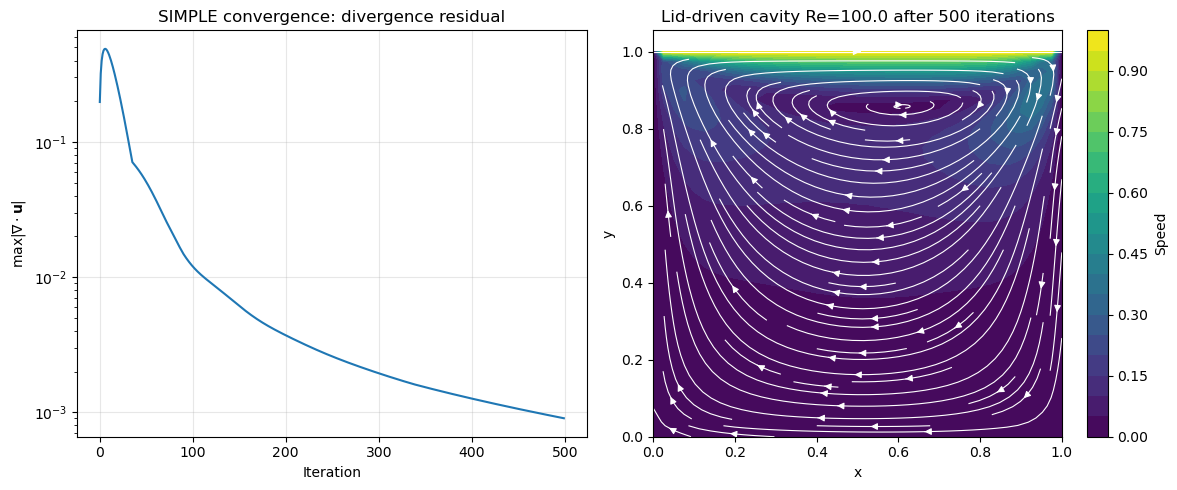

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def solve_poisson_jacobi(p, rhs, dx, dy, max_iter=50):
    """Iterative Poisson solver (Jacobi, fixed iterations)."""
    for _ in range(max_iter):
        p[1:-1, 1:-1] = (
            (p[1:-1, 2:] + p[1:-1, :-2]) / dx**2 +
            (p[2:, 1:-1] + p[:-2, 1:-1]) / dy**2 -
            rhs[1:-1, 1:-1]
        ) / (2/dx**2 + 2/dy**2)
        # Neumann BC
        p[0,:] = p[1,:]; p[-1,:] = p[-2,:]
        p[:,0] = p[:,1]; p[:,-1] = p[:,-2]
    p -= p.mean()
    return p

# Grid parameters
N     = 41
L     = 1.0
dx    = dy = L / (N - 1)
Re    = 100.0
nu    = 1.0 / Re
rho   = 1.0
dt    = 0.001
alpha_p = 0.1  # strong under-relaxation for stability

# Fields
u = np.zeros((N, N))
v = np.zeros((N, N))
p = np.zeros((N, N))

# Lid: top wall moves at u=1
u[-1, :] = 1.0

# Run a small number of outer iterations to show the SIMPLE loop structure
n_outer = 500
div_history = []

for outer in range(n_outer):
    u_star = u.copy()
    v_star = v.copy()

    # Momentum predictor (explicit Euler, simplified)
    # u-momentum
    u_star[1:-1, 1:-1] = (u[1:-1, 1:-1]
        - dt * (u[1:-1, 1:-1] * (u[1:-1, 1:-1] - u[1:-1, :-2]) / dx
              + v[1:-1, 1:-1] * (u[1:-1, 1:-1] - u[:-2, 1:-1]) / dy)
        - dt/rho * (p[1:-1, 2:] - p[1:-1, :-2]) / (2*dx)
        + dt * nu * ((u[1:-1, 2:] - 2*u[1:-1, 1:-1] + u[1:-1, :-2]) / dx**2
                   + (u[2:, 1:-1] - 2*u[1:-1, 1:-1] + u[:-2, 1:-1]) / dy**2))

    # v-momentum
    v_star[1:-1, 1:-1] = (v[1:-1, 1:-1]
        - dt * (u[1:-1, 1:-1] * (v[1:-1, 1:-1] - v[1:-1, :-2]) / dx
              + v[1:-1, 1:-1] * (v[1:-1, 1:-1] - v[:-2, 1:-1]) / dy)
        - dt/rho * (p[2:, 1:-1] - p[:-2, 1:-1]) / (2*dy)
        + dt * nu * ((v[1:-1, 2:] - 2*v[1:-1, 1:-1] + v[1:-1, :-2]) / dx**2
                   + (v[2:, 1:-1] - 2*v[1:-1, 1:-1] + v[:-2, 1:-1]) / dy**2))

    # Apply BCs to u*, v*
    u_star[0,:]=0; u_star[-1,:]=1.0; u_star[:,0]=0; u_star[:,-1]=0
    v_star[0,:]=0; v_star[-1,:]=0;   v_star[:,0]=0; v_star[:,-1]=0

    # Pressure Poisson — central differences so both terms give shape (N-2, N-2)
    div = (u_star[1:-1, 2:] - u_star[1:-1, :-2]) / (2*dx) + \
          (v_star[2:, 1:-1] - v_star[:-2, 1:-1]) / (2*dy)
    rhs_pp = np.zeros_like(p)
    rhs_pp[1:-1, 1:-1] = rho / dt * div

    p_prime = solve_poisson_jacobi(np.zeros_like(p), rhs_pp, dx, dy)

    # Correction
    u[1:-1, 1:-1] = u_star[1:-1, 1:-1] - dt/rho * (p_prime[1:-1, 2:] - p_prime[1:-1, :-2]) / (2*dx)
    v[1:-1, 1:-1] = v_star[1:-1, 1:-1] - dt/rho * (p_prime[2:, 1:-1] - p_prime[:-2, 1:-1]) / (2*dy)
    p += alpha_p * p_prime

    # Re-apply BCs
    u[0,:]=0; u[-1,:]=1.0; u[:,0]=0; u[:,-1]=0
    v[0,:]=0; v[-1,:]=0;   v[:,0]=0; v[:,-1]=0

    # Track divergence (same central-difference stencil)
    div_full = (u[1:-1, 2:] - u[1:-1, :-2]) / (2*dx) + (v[2:, 1:-1] - v[:-2, 1:-1]) / (2*dy)
    div_history.append(np.max(np.abs(div_full)))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].semilogy(div_history)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('$\\max|\\nabla\\cdot\\mathbf{u}|$')
axes[0].set_title('SIMPLE convergence: divergence residual')
axes[0].grid(True, alpha=0.3)

x = np.linspace(0, L, N)
y = np.linspace(0, L, N)
X, Y = np.meshgrid(x, y)
speed = np.sqrt(u**2 + v**2)
cf = axes[1].contourf(X, Y, speed, levels=20, cmap='viridis')
plt.colorbar(cf, ax=axes[1], label='Speed')
axes[1].streamplot(X, Y, u, v, color='white', density=1.2, linewidth=0.8)
axes[1].set_title(f'Lid-driven cavity Re={Re} after {n_outer} iterations')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y')

plt.tight_layout()
plt.show()

## Key Takeaways

- SIMPLE decouples the N-S system into: (1) solve momentum → $\mathbf{u}^*$; (2) solve PPE → $p'$; (3) correct $\mathbf{u}$, $p$.
- Under-relaxation is essential for stability: $\alpha_u \approx 0.7$, $\alpha_p \approx 0.3$.
- Convergence is measured by residuals: velocity residual + pressure (continuity) residual.
- SIMPLE is the foundation of ANSYS Fluent, OpenFOAM (simpleFoam), and many other codes.
- PISO (used in icoFoam) makes two correction steps per time step — better for unsteady flows.

---

**Next**: Lesson 2.6 — Lid-Driven Cavity: the "Hello World" of CFD, full implementation and validation.
